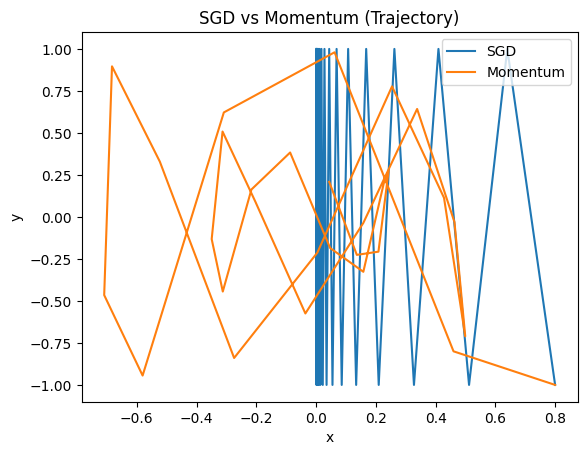

In [1]:
import torch
import matplotlib.pyplot as plt

# Function: f(x, y) = x^2 + 10y^2
def func(x, y):
    return x**2 + 10*y**2

# Tracking
sgd_points = []
mom_points = []

# Initial
x_sgd = torch.tensor([1.0, 1.0], requires_grad=True)
x_mom = torch.tensor([1.0, 1.0], requires_grad=True)

# Optimizers
opt_sgd = torch.optim.SGD([x_sgd], lr=0.1)
opt_mom = torch.optim.SGD([x_mom], lr=0.1, momentum=0.9)

for i in range(30):
    # --- SGD ---
    opt_sgd.zero_grad()
    loss_sgd = func(x_sgd[0], x_sgd[1])
    loss_sgd.backward()
    opt_sgd.step()
    sgd_points.append(x_sgd.detach().clone())

    # --- Momentum ---
    opt_mom.zero_grad()
    loss_mom = func(x_mom[0], x_mom[1])
    loss_mom.backward()
    opt_mom.step()
    mom_points.append(x_mom.detach().clone())

# Plot
sgd_np = torch.stack(sgd_points).numpy()
mom_np = torch.stack(mom_points).numpy()

plt.plot(sgd_np[:,0], sgd_np[:,1], label="SGD")
plt.plot(mom_np[:,0], mom_np[:,1], label="Momentum")
plt.legend()
plt.title("SGD vs Momentum (Trajectory)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [38]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Activation, BatchNormalization,Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
tf.config.run_functions_eagerly(True)
tf.compat.v1.enable_eager_execution()

In [49]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

In [50]:
input_layer = Input(shape=(28,28))
Flatten_layer = Flatten()(input_layer)
x = Dense(32)(Flatten_layer)
x = Activation('relu')(x)
x = Dense(16)(x)    
x = Activation('relu')(x)
output_layer = Dense(10,activation='softmax')(x)

sgd_model = Model(inputs=input_layer,outputs=output_layer)

In [51]:
sgd_optimizer = SGD(learning_rate=0.01)


In [52]:
sgd_model.compile(optimizer=sgd_optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [53]:
sgd_model_hist = sgd_model.fit(X_train,y_train,epochs=200,batch_size=32976,validation_data=(X_test,y_test))

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.1021 - loss: 2.3121 - val_accuracy: 0.1089 - val_loss: 2.3064
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1047 - loss: 2.3059 - val_accuracy: 0.1109 - val_loss: 2.3002
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1077 - loss: 2.2999 - val_accuracy: 0.1139 - val_loss: 2.2943
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.1103 - loss: 2.2941 - val_accuracy: 0.1176 - val_loss: 2.2885
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.1141 - loss: 2.2886 - val_accuracy: 0.1203 - val_loss: 2.2830
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1173 - loss: 2.2832 - val_accuracy: 0.1256 - val_loss: 2.2776
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1213 - loss: 2.2779 - val_accuracy: 0.1290 - val_loss: 2.2722
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1247 - loss: 2.2728 - val_accuracy: 0.1310 - val_l

In [54]:
input_layer = Input(shape=(28,28))
Flatten_layer = Flatten()(input_layer)
x = Dense(32)(Flatten_layer)
x = Activation('relu')(x)
x = Dense(16)(x)    
x = Activation('relu')(x)
output_layer = Dense(10,activation='softmax')(x)

momentum_optimizer = SGD(learning_rate=0.01,momentum=0.9)

momentum_model = Model(inputs=input_layer,outputs=output_layer)
momentum_model.compile(optimizer=momentum_optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [55]:
momentum_model_hist = momentum_model.fit(X_train,y_train,epochs=200,batch_size=32976,validation_data=(X_test,y_test))

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.0915 - loss: 2.3872 - val_accuracy: 0.0898 - val_loss: 2.3817
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.0926 - loss: 2.3704 - val_accuracy: 0.0938 - val_loss: 2.3549
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.0980 - loss: 2.3427 - val_accuracy: 0.1077 - val_loss: 2.3228
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1136 - loss: 2.3113 - val_accuracy: 0.1341 - val_loss: 2.2920
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1463 - loss: 2.2820 - val_accuracy: 0.1784 - val_loss: 2.2660
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1937 - loss: 2.2574 - val_accuracy: 0.2300 - val_loss: 2.2443
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2439 - loss: 2.2361 - val_accuracy: 0.2698 - val_loss: 2.2238
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2810 - loss: 2.2154 - val_accuracy: 0.2991 - v

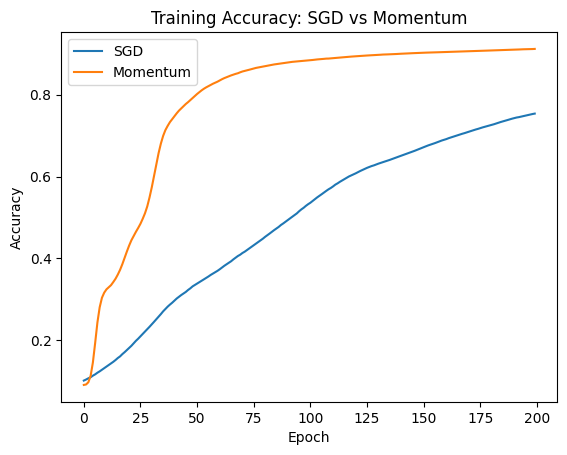

In [56]:
plt.plot(sgd_model_hist.history['accuracy'], label="SGD")
plt.plot(momentum_model_hist.history['accuracy'], label="Momentum")
plt.title("Training Accuracy: SGD vs Momentum")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

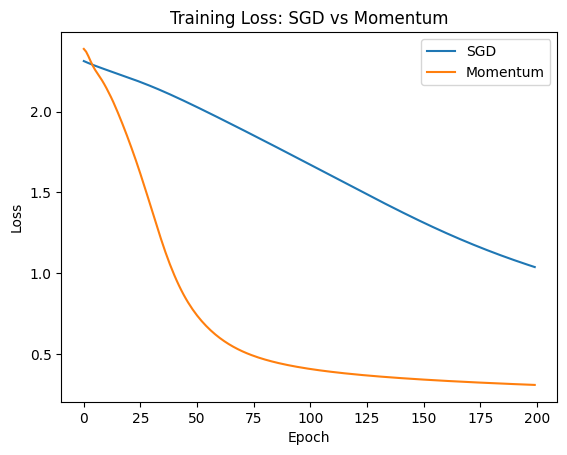

In [57]:
plt.plot(sgd_model_hist.history['loss'], label="SGD")
plt.plot(momentum_model_hist.history['loss'], label="Momentum")
plt.title("Training Loss: SGD vs Momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()